# load modules

In [1]:
from itertools import combinations

In [2]:
!pip install optuna

In [3]:
# =========================
# System & File Management
# =========================
import os
import re
import time
import json
import copy
import pickle
from pathlib import Path
import warnings

# =========================
# Data Handling & Numerical
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# =========================
# Statistics
# =========================
from scipy.stats import chi2_contingency, mannwhitneyu

# =========================
# Machine Learning - Preprocessing
# =========================
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.utils import resample
from sklearn.metrics import log_loss

# =========================
# Machine Learning - Modeling & Evaluation
# =========================
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

# =========================
# Optimization
# =========================
import optuna
from optuna.pruners import HyperbandPruner  # or MedianPruner
from optuna.samplers import TPESampler

# =========================
# XGBoost
# =========================
# from xgboost import XGBClassifier
import xgboost as xgb

# =========================
# Deep Learning (PyTorch)
# =========================
import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================
# Dimensionality Reduction & Clustering
# =========================
import umap
import hdbscan

# =========================
# Utilities
# =========================
from tqdm import tqdm
import joblib

# =========================
# Warnings Configuration
# =========================
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn.impute')
os.environ['PYTHONWARNINGS'] = 'ignore'


# Functions

In [4]:
torch.manual_seed(42)
np.random.seed(42)

In [5]:
def filter_data_by_clusters(X, y, cluster_df, clusters_to_include):
    keep_ids = cluster_df.loc[
        cluster_df["cluster"].isin(clusters_to_include),
        "sample_id"
    ]
    print(f"combine {clusters_to_include}  keep_ids size: {len(keep_ids)}")

    keep_ids = pd.Index(keep_ids).intersection(X.index)
    print(f" X.index size : {len(keep_ids)}")

    X_sub = X.loc[keep_ids].copy()
    y_sub = y.loc[keep_ids].copy()
    return X_sub, y_sub

def evaluate_model_on_test_set_with_shap(
    X_test,
    y_test,
    model_path,
    n_bootstrap=1000,
    output_dir='./boots_output',
    output_csv_name='test_results.csv',
    random_seed=42
):

    os.makedirs(output_dir, exist_ok=True)

    # ------------------- 1️⃣ load the model -------------------
    model = xgb.Booster()
    model.load_model(model_path)
    dtest = xgb.DMatrix(X_test)
    test_preds_proba = model.predict(dtest)

    # ------------------- 2️⃣ calculate the AUPRC -------------------
    test_auc = roc_auc_score(y_test, test_preds_proba)
    test_auprc = average_precision_score(y_test, test_preds_proba)
    test_logloss = log_loss(y_test, test_preds_proba)

    # ------------------- 3️⃣ Bootstrap -------------------
    rng = np.random.default_rng(seed=random_seed)
    aucs, auprcs, loglosses = [], [], []

    for _ in range(n_bootstrap):
        indices = rng.choice(len(y_test), size=len(y_test), replace=True)
        y_true_boot = y_test.iloc[indices] if isinstance(y_test, pd.Series) else y_test[indices]
        y_pred_boot = test_preds_proba[indices]
        if len(np.unique(y_true_boot)) < 2:
            continue
        aucs.append(roc_auc_score(y_true_boot, y_pred_boot))
        auprcs.append(average_precision_score(y_true_boot, y_pred_boot))
        loglosses.append(log_loss(y_true_boot, y_pred_boot))

    aucs = np.array(aucs)
    auprcs = np.array(auprcs)
    loglosses = np.array(loglosses)

    auc_ci = np.percentile(aucs, [2.5, 97.5])
    auprc_ci = np.percentile(auprcs, [2.5, 97.5])
    logloss_ci = np.percentile(loglosses, [2.5, 97.5])

    # ------------------- 3️⃣ p-value -------------------
    # baseline
    baseline_auc = 0.5
    baseline_auprc = y_test.mean()  # random guess AUPRC
    baseline_logloss = log_loss(y_test, np.full_like(y_test, baseline_auprc))

    pval_auc = np.mean(aucs <= baseline_auc)
    pval_auprc = np.mean(auprcs <= baseline_auprc)
    pval_logloss = np.mean(loglosses >= baseline_logloss)  # lower is better

    print(f"AUC: {test_auc:.4f} (95% CI: {auc_ci[0]:.4f}-{auc_ci[1]:.4f}), p={pval_auc:.4f}")
    print(f"AUPRC: {test_auprc:.4f} (95% CI: {auprc_ci[0]:.4f}-{auprc_ci[1]:.4f}), p={pval_auprc:.4f}")
    print(f"LogLoss: {test_logloss:.4f} (95% CI: {logloss_ci[0]:.4f}-{logloss_ci[1]:.4f}), p={pval_logloss:.4f}")

    # ------------------- 4️⃣ save bootstrap output -------------------
    bootstrap_df = pd.DataFrame({'auc': aucs, 'auprc': auprcs, 'logloss': loglosses})
    csv_path = os.path.join(output_dir, output_csv_name)
    bootstrap_df.to_csv(csv_path, index=False)

    # box plot
    bootstrap_df_long = bootstrap_df.melt(var_name='Metric', value_name='Score')
    plt.figure(figsize=(8,6))
    sns.boxplot(data=bootstrap_df_long, x='Metric', y='Score', palette='Set2')
    plt.title(f'Bootstrap Metrics (n={len(y_test)})')
    plt.tight_layout()
    plt.savefig(csv_path.replace('.csv', '.png'))
    plt.close()

    # ------------------- 5️⃣ SHAP analysis -------------------
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    shap_df = pd.DataFrame(shap_values, columns=X_test.columns, index=X_test.index)
    shap_csv_path = csv_path.replace('.csv', '_shap.csv')
    shap_df.to_csv(shap_csv_path)

    shap.summary_plot(shap_values, X_test, show=False)
    shap_png_path = csv_path.replace('.csv', '_shap.png')
    plt.savefig(shap_png_path)
    plt.close()

    # ------------------- 6️⃣ return the results -------------------
    return {
        "auc": test_auc, "auc_ci": auc_ci, "auc_pval": pval_auc,
        "auprc": test_auprc, "auprc_ci": auprc_ci, "auprc_pval": pval_auprc,
        "logloss": test_logloss, "logloss_ci": logloss_ci, "logloss_pval": pval_logloss,
        "bootstrap_df": bootstrap_df,
        "shap_values": shap_df
    }




def retrain_and_evaluate_all_cluster_combinations(
    cluster_csv_path,
    X_train, y_train,
    X_test, y_test,
    clusters_to_include,
    min_comb_size=1,
    max_comb_size=2,
    n_bootstrap=1000,
    output_dir="./cluster_retrain_results",
    random_seed=42
):
    os.makedirs(output_dir, exist_ok=True)

    # ================== 1️⃣ readin CSV  ==================
    cluster_df = pd.read_csv(cluster_csv_path)
    cluster_df = cluster_df.rename(columns={
        "sample_index": "sample_id",
        "cluster_id": "cluster"
    })
    cluster_df["sample_id"] = cluster_df["sample_id"].astype(str)

    # keep index the same
    X_train.index = X_train.index.astype(str)
    X_test.index = X_test.index.astype(str)
    y_train.index = y_train.index.astype(str)
    y_test.index = y_test.index.astype(str)

    # ================== 2️⃣ list cluster combination ==================
    all_combs = []
    for k in range(min_comb_size, max_comb_size + 1):
        all_combs.extend(list(combinations(clusters_to_include, k)))

    results_summary = []
    skipped_records = []

    for comb in tqdm(all_combs, desc="Cluster combinations"):
        comb_name = "_".join(map(str, comb))
        print(f"\n🚀 Cluster 组合重新训练: {comb_name}")

        try:
            # ================== 3️⃣  cluster & set wise train / val ==================
            X_tr, y_tr = filter_data_by_clusters(
                X_train, y_train,
                cluster_df[cluster_df["set"]=="train"],
                comb
            )
            X_te, y_te = filter_data_by_clusters(
                X_test, y_test,
                cluster_df[cluster_df["set"]=="val"],
                comb
            )

            # QC：样本量 & 正样本
            if len(y_tr) < 50:
                raise ValueError("little for training")
            if y_tr.sum() == 0 or y_te.sum() == 0:
                raise ValueError("no positive cases")

            # ================== 4️⃣ train / internal val split ==================
            X_subtr, X_val, y_subtr, y_val = train_test_split(
                X_tr, y_tr,
                test_size=0.2,
                stratify=y_tr,
                random_state=random_seed
            )

            # ================== 5️⃣ retrain ==================
            eval_results = run_single_train_val(
                X_train=X_subtr,
                y_train=y_subtr,
                X_val=X_val,
                y_val=y_val,
                feature_names=X_tr.columns.tolist(),
                hospital_id=f"19_cluster_{comb_name}",
                random_state=random_seed
            )

            # ================== 6️⃣ test set bootstrap evaluation ==================
            test_result = evaluate_model_on_test_set_with_shap(
                X_test=X_te,
                y_test=y_te,
                model_path=eval_results["final_model_path"],
                n_bootstrap=1000,
                output_dir="./cluster_retrain_results",
                output_csv_name=f"cluster_{comb_name}_test.csv"
            )

            # ================== 7️⃣ save the output ==================
            results_summary.append({
                "combination": comb_name,
                "num_train": len(y_tr),
                "num_test": len(y_te),
                "positive_rate_test": y_te.mean(),
                "auc": test_result["auc"],
                "auc_ci_lower": test_result["auc_ci"][0],
                "auc_ci_upper": test_result["auc_ci"][1],
                "auc_pval": test_result["auc_pval"],         # <-- added
                "auprc": test_result["auprc"],
                "auprc_ci_lower": test_result["auprc_ci"][0],
                "auprc_ci_upper": test_result["auprc_ci"][1],
                "auprc_pval": test_result["auprc_pval"],     # <-- added
                "logloss": test_result["logloss"],
                "logloss_ci_lower": test_result["logloss_ci"][0],
                "logloss_ci_upper": test_result["logloss_ci"][1],
                "logloss_pval": test_result["logloss_pval"]  # <-- added
            })


        except Exception as e:
            print(f"❌ Cluster {comb_name} 失败: {e}")
            skipped_records.append({
                "combination": comb_name,
                "error": str(e)
            })

    # ================== 8️⃣ save all outputs ==================
    pd.DataFrame(results_summary).to_csv(
        os.path.join(output_dir, "summary_cluster_retrained_models.csv"),
        index=False
    )
    pd.DataFrame(skipped_records).to_csv(
        os.path.join(output_dir, "skipped_cluster_retrained_models.csv"),
        index=False
    )

    print(f"\n✅  retrained done and saved to {output_dir}")

In [6]:

def evaluate_model_with_bootstrap(
    cluster_csv_path,
    X_target_test,
    y_target_test,
    model_path,
    clusters_to_include=[1, 2, 3],
    n_bootstrap=1000,
    output_dir='/content/boots_output',
    output_csv_name='all-test-1.csv',
    random_seed=42
):
    df_2 = pd.read_csv(cluster_csv_path)
    index_to_cluster = df_2.set_index("sample_index")["cluster_id"]
    X_target_test["cluster_id"] = X_target_test.index.map(index_to_cluster)
    null_count = X_target_test['cluster_id'].isnull().sum()
    print(f"missing cluster_id id: {null_count}")

    mask = X_target_test['cluster_id'].isin(clusters_to_include)
    X_target_test_sub = X_target_test[mask]
    y_target_test_sub = y_target_test[mask.values]
    num_samples = len(X_target_test_sub)
    pos_rate = y_target_test_sub.mean() * 100
    print(f"➡️ combination {clusters_to_include}：sample size {num_samples}, Positive Rate: {pos_rate:.2f}%")

    if len(np.unique(y_target_test_sub)) < 2:
        label_val = y_target_test_sub[0]
        print(f"⚠️ only one type of data (label={label_val})，skip evaluation")
        return None

    X_target_test_sub = X_target_test_sub.drop(columns=['cluster_id'])

    model = xgb.Booster()
    model.load_model(model_path)
    dtest = xgb.DMatrix(X_target_test_sub)
    test_preds_proba = model.predict(dtest)

    test_auc = roc_auc_score(y_target_test_sub, test_preds_proba)
    test_auprc = average_precision_score(y_target_test_sub, test_preds_proba)
    test_logloss = log_loss(y_target_test_sub, test_preds_proba)

    print(f"🎯 test AUC: {test_auc:.4f}")
    print(f"🎯 test AUPRC: {test_auprc:.4f}")
    print(f"🎯 test LogLoss: {test_logloss:.4f}")

    rng = np.random.default_rng(seed=random_seed)
    aucs, auprcs, loglosses = [], [], []
    for _ in range(n_bootstrap):
        indices = rng.choice(len(y_target_test_sub), size=len(y_target_test_sub), replace=True)
        y_true_boot = y_target_test_sub[indices]
        y_pred_boot = test_preds_proba[indices]
        if len(np.unique(y_true_boot)) < 2:
            continue
        aucs.append(roc_auc_score(y_true_boot, y_pred_boot))
        auprcs.append(average_precision_score(y_true_boot, y_pred_boot))
        loglosses.append(log_loss(y_true_boot, y_pred_boot))

    auc_ci = np.percentile(aucs, [2.5, 97.5])
    auprc_ci = np.percentile(auprcs, [2.5, 97.5])
    logloss_ci = np.percentile(loglosses, [2.5, 97.5])

    # ================== p-value 计算 ==================
    baseline_auc = 0.5
    baseline_auprc = y_target_test_sub.mean()
    baseline_logloss = log_loss(
        y_target_test_sub,
        np.full_like(y_target_test_sub, baseline_auprc, dtype=float)
    )

    pval_auc = np.mean(np.array(aucs) <= baseline_auc)
    pval_auprc = np.mean(np.array(auprcs) <= baseline_auprc)
    pval_logloss = np.mean(np.array(loglosses) >= baseline_logloss)


    print(f"✅ test AUC: {test_auc:.4f} (95% CI: {auc_ci[0]:.4f} - {auc_ci[1]:.4f})")
    print(f"✅ test AUPRC: {test_auprc:.4f} (95% CI: {auprc_ci[0]:.4f} - {auprc_ci[1]:.4f})")
    print(f"✅ test LogLoss: {test_logloss:.4f} (95% CI: {logloss_ci[0]:.4f} - {logloss_ci[1]:.4f})")

    os.makedirs(output_dir, exist_ok=True)

    # save bootstrap output
    bootstrap_df = pd.DataFrame({'auc': aucs, 'auprc': auprcs, 'logloss': loglosses})
    csv_path = os.path.join(output_dir, output_csv_name)
    bootstrap_df.to_csv(csv_path, index=False)

    # plot
    bootstrap_df_long = bootstrap_df.melt(var_name='Metric', value_name='Score')
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=bootstrap_df_long, x='Metric', y='Score', palette='Set2')
    plt.title(f'Bootstrap Metrics (n={num_samples}, pos={pos_rate:.1f}%)')
    plt.tight_layout()
    png_path = csv_path.replace('.csv', '.png')
    plt.savefig(png_path)
    plt.close()

    # SHAP value
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_target_test_sub)
    shap_df = pd.DataFrame(shap_values, columns=X_target_test_sub.columns, index=X_target_test_sub.index)
    shap_csv_path = csv_path.replace('.csv', '_shap.csv')
    shap_df.to_csv(shap_csv_path)

    shap.summary_plot(shap_values, X_target_test_sub, show=False)
    shap_png_path = csv_path.replace('.csv', '_shap.png')
    plt.savefig(shap_png_path)
    plt.close()

    return {
        "auc": test_auc, "auc_ci": auc_ci, "auc_pval": pval_auc,
        "auprc": test_auprc, "auprc_ci": auprc_ci, "auprc_pval": pval_auprc,
        "logloss": test_logloss, "logloss_ci": logloss_ci, "logloss_pval": pval_logloss,
        "bootstrap_df": bootstrap_df,
        "num_samples": num_samples,
        "positive_rate": pos_rate
    }

def evaluate_all_cluster_combinations(
    cluster_csv_path,
    X_target_test,
    y_target_test,
    model_path,
    clusters_to_include,
    min_comb_size=1,
    max_comb_size=2,
    n_bootstrap=1000,
    output_dir='./results',
    random_seed=42
):
    os.makedirs(output_dir, exist_ok=True)
    all_combs = []
    for k in range(min_comb_size, max_comb_size + 1):
        all_combs.extend(list(combinations(clusters_to_include, k)))

    results_summary = []
    skipped_records = []

    for comb in tqdm(all_combs):
        comb_name = "_".join(map(str, comb))
        output_csv = f"cluster_{comb_name}_results.csv"
        try:
            result = evaluate_model_with_bootstrap(
                cluster_csv_path=cluster_csv_path,
                X_target_test=X_target_test.copy(),
                y_target_test=y_target_test.copy(),
                model_path=model_path,
                clusters_to_include=list(comb),
                n_bootstrap=n_bootstrap,
                output_dir=output_dir,
                output_csv_name=output_csv,
                random_seed=random_seed
            )
            if result is not None:
                results_summary.append({
                    "combination": comb_name,
                    "num_samples": result["num_samples"],
                    "positive_rate": result["positive_rate"],

                    "auc": result["auc"],
                    "auc_ci_lower": result["auc_ci"][0],
                    "auc_ci_upper": result["auc_ci"][1],
                    "auc_pval": result["auc_pval"],

                    "auprc": result["auprc"],
                    "auprc_ci_lower": result["auprc_ci"][0],
                    "auprc_ci_upper": result["auprc_ci"][1],
                    "auprc_pval": result["auprc_pval"],

                    "logloss": result["logloss"],
                    "logloss_ci_lower": result["logloss_ci"][0],
                    "logloss_ci_upper": result["logloss_ci"][1],
                    "logloss_pval": result["logloss_pval"]
                })

        except Exception as e:
            print(f"❌ combination {comb_name} raise error: {e}")
            skipped_records.append({"combination": comb_name, "error": str(e)})

    summary_df = pd.DataFrame(results_summary)
    summary_path = os.path.join(output_dir, "summary_results.csv")
    summary_df.to_csv(summary_path, index=False)

    skipped_path = os.path.join(output_dir, "skipped_combinations.csv")
    pd.DataFrame(skipped_records).to_csv(skipped_path, index=False)
    print(f"✅ saved output folder {output_dir}")



def bootstrap_metrics(y_true, y_pred_prob, y_pred, n_bootstrap=1000, random_state=42):
    rng = np.random.default_rng(seed=42)
    metrics_boot = {
        'auprc': [],
        'auroc': [],
        'logloss': [],
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': []
    }
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = rng.choice(n, n, replace=True)
        yt = y_true[idx]
        yp_prob = y_pred_prob[idx]
        yp = y_pred[idx]
        
        if len(np.unique(yt)) < 2:
            continue
        metrics_boot['auprc'].append(average_precision_score(yt, yp_prob))
        metrics_boot['auroc'].append(roc_auc_score(yt, yp_prob))
        metrics_boot['logloss'].append(log_loss(yt, yp_prob))
        metrics_boot['accuracy'].append(accuracy_score(yt, yp))
        metrics_boot['precision'].append(precision_score(yt, yp, zero_division=0))
        metrics_boot['recall'].append(recall_score(yt, yp, zero_division=0))
        metrics_boot['f1'].append(f1_score(yt, yp, zero_division=0))

    # 95% CI
    summary = {}
    for k, vals in metrics_boot.items():
        vals = np.array(vals)
        mean = np.mean(vals)
        lower = np.percentile(vals, 2.5)
        upper = np.percentile(vals, 97.5)
        summary[k] = (mean, lower, upper)
    return summary


def run_single_train_val(X_train, y_train, X_val, y_val, model_name='xgboost',
                         feature_names=None, num_clusters=5, tune_params=False,
                         n_trials=20, hospital_id=None, random_state=42):

    save_folder = f'saved_models_{model_name}_single'
    os.makedirs(save_folder, exist_ok=True)

    print(f"【{model_name.upper()}】start  - {time.strftime('%Y-%m-%d %H:%M:%S')}")
    model_filename = f'best_{model_name}_{hospital_id}.model' if hospital_id else f'best_{model_name}.model'
    model_path = os.path.join(save_folder, model_filename)
    print(f"✅ output model path: {model_path}")

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)


    pos = np.sum(y_train)
    neg = len(y_train) - pos
    scale_pos_weight = neg / pos if pos > 0 else 1.0

    params = {
        'objective': 'binary:logistic',
        'eval_metric': ['aucpr', 'logloss'],
        'learning_rate': 0.01,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'seed': random_state,
        'nthread': 1,
        'verbosity': 0,
        'scale_pos_weight': scale_pos_weight
    }

    if tune_params:
        best_score = -1
        best_params = params.copy()
        for depth, lr in itertools.product([4, 6, 8], [0.01, 0.05, 0.1]):
            tmp_params = params.copy()
            tmp_params.update({'max_depth': depth, 'learning_rate': lr})
            bst_tmp = xgb.train(tmp_params, dtrain, num_boost_round=100,
                                evals=[(dval, 'eval')], verbose_eval=False)
            preds = bst_tmp.predict(dval)
            score = average_precision_score(y_val, preds)
            if score > best_score:
                best_score = score
                best_params.update({'max_depth': depth, 'learning_rate': lr})
        params = best_params
        print(f"🔧 done parameter tuning | best max_depth={params['max_depth']}, learning_rate={params['learning_rate']}")

    print(f"\n🏗️ training model {model_name}...")
    start_time = time.time()

    bst = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=1000,
        evals=[(dtrain, 'train'), (dval, 'eval')],
        early_stopping_rounds=10,
        verbose_eval=20
    )

    train_time = time.time() - start_time
    print(f"✅ done training | time consumed: {train_time:.1f}s")

    print("\n📊 evaluate model performance...")
    val_preds = bst.predict(dval)

    auroc = roc_auc_score(y_val, val_preds)
    auprc = average_precision_score(y_val, val_preds)
    accuracy = accuracy_score(y_val, val_preds > 0.5)

    n_bootstrap = 1000
    auroc_samples = []
    auprc_samples = []

    for _ in tqdm(range(n_bootstrap), desc="Bootstrap evaluation"):
        idx = resample(np.arange(len(y_val)), stratify=y_val)
        auroc_samples.append(roc_auc_score(y_val[idx], val_preds[idx]))
        auprc_samples.append(average_precision_score(y_val[idx], val_preds[idx]))

    auroc_ci = np.percentile(auroc_samples, [2.5, 97.5])
    auprc_ci = np.percentile(auprc_samples, [2.5, 97.5])

    bst.save_model(model_path)


    feature_importances = {}
    if feature_names is not None:
        fmap = {f'f{i}': name for i, name in enumerate(feature_names)}
        score = bst.get_score(importance_type='weight')
        for k, v in score.items():
            feature_importances[fmap.get(k, k)] = v

    eval_results = {
        'metrics': {
            'auroc': auroc,
            'auroc_ci': list(auroc_ci),
            'auprc': auprc,
            'auprc_ci': list(auprc_ci),
            'accuracy': accuracy,
            'train_time_s': train_time
        },
        'model_path': model_path,
        'feature_importances': feature_importances
    }

    print("\n🎯 outputs:")
    print(f"AUROC: {auroc:.4f} (95% CI: {auroc_ci[0]:.4f} - {auroc_ci[1]:.4f})")
    print(f"AUPRC: {auprc:.4f} (95% CI: {auprc_ci[0]:.4f} - {auprc_ci[1]:.4f})")
    print(f"Accuracy: {accuracy:.4f}")

    # ============ 🔁 retrain on full train+val ==============
    dfull = xgb.DMatrix(np.concatenate([X_train, X_val]), label=np.concatenate([y_train, y_val]))

    bst_final = xgb.train(
        params=params,
        dtrain=dfull,
        num_boost_round=bst.best_iteration + 1
    )

    final_model_path = model_path.replace('.model', '_final.model')
    bst_final.save_model(final_model_path)

    print(f"✅ final model saved to: {final_model_path}")
    eval_results['final_model_path'] = final_model_path

    return eval_results


def plot_and_metrics(embedding, cluster_labels, y, X, X_index, model, save_folder, prefix):
    reduced_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'], index=X_index)
    reduced_df['cluster'] = cluster_labels
    reduced_df['true'] = y.values

    plt.figure(figsize=(10, 8))
    unique_clusters = np.unique(cluster_labels)
    n_clusters = len(unique_clusters[unique_clusters >= 0])
    palette = sns.color_palette('tab10', n_clusters if n_clusters > 0 else 1)

    sns.scatterplot(
        data=reduced_df,
        x='UMAP1',
        y='UMAP2',
        hue='cluster',
        palette=palette,
        alpha=0.7,
        legend='full',
        hue_order=[c for c in sorted(unique_clusters) if c >= 0]
    )
    plt.title(f'UMAP + HDBSCAN Clustering on SHAP values ({prefix} set)')
    plt.savefig(os.path.join(save_folder, f'umap_hdbscan_clusters_{prefix}.png'), dpi=300, bbox_inches='tight')
    plt.close()

    plt.figure(figsize=(8, 5))
    sns.barplot(data=reduced_df[reduced_df['cluster'] >= 0], x='cluster', y='true', estimator=np.mean, ci=None)
    plt.ylabel('True label positive rate')
    plt.title(f'True label distribution per cluster ({prefix} set)')
    plt.savefig(os.path.join(save_folder, f'cluster_true_distribution_{prefix}.png'), dpi=300, bbox_inches='tight')
    plt.close()

    print(f"calculate {prefix} cluster ...")
    y_pred = model.predict(X)
    if hasattr(y_pred, 'shape') and len(y_pred.shape) == 2:
        y_pred = (y_pred[:, 1] if y_pred.shape[1] > 1 else y_pred[:, 0]) > 0.5
        y_pred = y_pred.astype(int)

    non_noise_mask = cluster_labels != -1
    y_non_noise = y[non_noise_mask]
    y_pred_non_noise = y_pred[non_noise_mask]

    overall_metrics = {
        "accuracy": accuracy_score(y_non_noise, y_pred_non_noise),
        "precision": precision_score(y_non_noise, y_pred_non_noise, zero_division=0),
        "recall": recall_score(y_non_noise, y_pred_non_noise, zero_division=0),
        "f1": f1_score(y_non_noise, y_pred_non_noise, zero_division=0)
    }

    cluster_stats = []
    for cluster_id in np.unique(cluster_labels):
        idx = np.where(cluster_labels == cluster_id)[0]
        y_true_c = y.iloc[idx]
        y_pred_c = y_pred[idx]

        metrics_c = {
            "cluster_id": cluster_id,
            "num_samples": len(idx),
            "accuracy": accuracy_score(y_true_c, y_pred_c),
            "precision": precision_score(y_true_c, y_pred_c, zero_division=0),
            "recall": recall_score(y_true_c, y_pred_c, zero_division=0),
            "f1": f1_score(y_true_c, y_pred_c, zero_division=0),
            "true_rate": y_true_c.mean(),
            "pred_rate": y_pred_c.mean()
        }

        for metric in ["accuracy", "precision", "recall", "f1"]:
            base = overall_metrics[metric]
            value = metrics_c[metric]
            metrics_c[f"{metric}_vs_overall"] = (
                "above average" if value > base else
                "equal" if np.isclose(value, base, atol=1e-4) else
                "below average"
            )
        cluster_stats.append(metrics_c)

    cluster_stats_df = pd.DataFrame(cluster_stats)
    cluster_stats_df.to_csv(os.path.join(save_folder, f'cluster_metrics_summary_{prefix}.csv'), index=False)
    print(f"{prefix} cluster assignment saved to ：{os.path.join(save_folder, f'cluster_metrics_summary_{prefix}.csv')}")


def generate_shap_umap_hdbscan_analysis(model, X_train, y_train, X_val, y_val,
                                        feature_names=None, save_folder='./results',
                                        k_neighbors=5):
    os.makedirs(save_folder, exist_ok=True)

    if feature_names is None:
        feature_names = [f'feature_{i}' for i in range(X_train.shape[1])]

    if isinstance(y_train, np.ndarray):
        y_train = pd.Series(y_train, index=X_train.index)
    if isinstance(y_val, np.ndarray):
        y_val = pd.Series(y_val, index=X_val.index)

    print("calculate SHAP on train set...")
    explainer = shap.TreeExplainer(model)
    shap_values_train = explainer.shap_values(X_train)
    if isinstance(shap_values_train, list):
        shap_values_train = shap_values_train[1]
    if len(shap_values_train.shape) == 3:
        shap_values_train = shap_values_train[:, :, 1]

    scaler = StandardScaler()
    shap_scaled_train = scaler.fit_transform(shap_values_train)

    print(" UMAP on train set...")
    reducer = umap.UMAP(n_components=2, random_state=42)
    embedding_train = reducer.fit_transform(shap_scaled_train)

    print(" HDBSCAN cluster on train set...")
    clusterer = hdbscan.HDBSCAN(min_cluster_size=30) #19
    cluster_labels_train = clusterer.fit_predict(embedding_train)

    print("calculate SHAP and apply KNN...")
    shap_values_val = explainer.shap_values(X_val)
    if isinstance(shap_values_val, list):
        shap_values_val = shap_values_val[1]
    if len(shap_values_val.shape) == 3:
        shap_values_val = shap_values_val[:, :, 1]

    shap_scaled_val = scaler.transform(shap_values_val)
    embedding_val = reducer.transform(shap_scaled_val)

    nn = NearestNeighbors(n_neighbors=k_neighbors).fit(embedding_train)
    _, indices = nn.kneighbors(embedding_val)
    neighbor_labels = cluster_labels_train[indices]  # shape: (n_val_samples, k)

    def majority_vote(labels_row):
        labels, counts = np.unique(labels_row, return_counts=True)
        if len(labels) == 0:
            return -1
        if (labels == -1).any() and counts[labels == -1][0] > k_neighbors // 2:
            return -1
        non_noise = [(l, c) for l, c in zip(labels, counts) if l != -1]
        if len(non_noise) == 0:
            return -1
        return max(non_noise, key=lambda x: x[1])[0]

    cluster_labels_val = np.apply_along_axis(majority_vote, axis=1, arr=neighbor_labels)

    plot_and_metrics(embedding_train, cluster_labels_train, y_train, X_train, X_train.index, model, save_folder, prefix='train')
    # plot_and_metrics(embedding_val, cluster_labels_val, y_val, X_val, X_val.index, model, save_folder, prefix='val')

    sample_clusters_combined = pd.DataFrame({
        'sample_index': pd.concat([X_train.index.to_series(), X_val.index.to_series()]),
        'set': ['train'] * len(X_train) + ['val'] * len(X_val),
        'cluster_id': np.concatenate([cluster_labels_train, cluster_labels_val])
    })
    sample_clusters_combined.to_csv(os.path.join(save_folder, 'sample_cluster_assignments_combined.csv'), index=False)

    print("✅ SHAP + UMAP + HDBSCAN done：", save_folder)


def run_shap_umap_hdbscan_analysis(k_neighbors, model_path, hospital_id):
    base_folder = f'/content/cluster_{hospital_id}'
    os.makedirs(base_folder, exist_ok=True)

    save_folder = os.path.join(base_folder, f'{hospital_id}_{k_neighbors}')
    os.makedirs(save_folder, exist_ok=True)

    booster = xgb.Booster()
    booster.load_model(model_path)

    model = xgb.XGBClassifier()
    model._Booster = booster

    generate_shap_umap_hdbscan_analysis(
        model,
        X_target_train,
        y_target_train,
        X_target_test,
        y_target_test,
        save_folder=save_folder,
        k_neighbors=7
    )




In [7]:
 !rm -r cluster* model

rm: cannot remove 'model': No such file or directory


# data load and preprocession

In [8]:
# !rm -r boot* cluster* model* test*

In [9]:
df = pd.read_csv('/content/gossis-1-eicu-only.csv')

In [10]:
df.head(2)

,patientunitstayid,data_source,encounter_id,hospital_id,patient_id,age,bmi,country,elective_surgery,ethnicity,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,141194,eicu,eicu_141194,73,eicu_002-5276,68.0,22.732803,USA,0,Caucasian,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,141203,eicu,eicu_141203,66,eicu_002-23234,77.0,27.421875,USA,0,Caucasian,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory


In [11]:
df['hospital_id'].value_counts().head(5).index
top_hospitals = df['hospital_id'].value_counts().head(3).index

df_top3 = df[df['hospital_id'].isin(top_hospitals)]

In [12]:
df_top3['hospital_id'].value_counts()

,count
hospital_id,
73,4333
264,3925
338,3095


In [13]:
df_top1 = df[df['hospital_id'] == 73] # done

In [14]:
mask = df_top1['gcs_unable_apache'] == 1

df_top1.loc[mask, ['gcs_eyes_apache', 'gcs_motor_apache', 'gcs_verbal_apache']] = 0

In [15]:
df_top1['readmission_status'].value_counts()

,count
readmission_status,
0,4333


In [16]:
df_top1['data_source'].value_counts()

,count
data_source,
eicu,4333


In [17]:
df_top1['hospital_bed_size'].value_counts(dropna= False)

,count
hospital_bed_size,
>= 500,4333


In [18]:
# include the columns 'death_prob'
death_prob_cols = df_top1.columns[df_top1.columns.str.contains('death_prob')]

# print those columns
print("Columns containing 'death_prob':", list(death_prob_cols))

# print the number
print("Number of columns containing 'death_prob':", len(death_prob_cols))


Columns containing 'death_prob': ['apache_3j_hospital_death_prob', 'apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob']
Number of columns containing 'death_prob': 3


In [19]:
cols_to_drop = [
    'hospital_death',
    'hospital_disch_location',
    # 'icu_death',
    'icu_disch_location',
    'icu_los_days',
    # 'pre_icu_los_days',
    'apache_3j_score',
    'apache_4a_hospital_death_prob',
    'apache_4a_icu_death_prob',
    'apache_3j_hospital_death_prob',
    'apsiii',
    'hospital_los_days',
    'encounter_id',
    'patient_id'
]

df_top1 = df_top1.drop(columns=cols_to_drop)

In [20]:

gcs_unable_1_rows = df_top1[df_top1['gcs_unable_apache'].isna()]

print("这些行中各个 GCS 分量的缺失情况：")
print(gcs_unable_1_rows[['gcs_eyes_apache', 'gcs_motor_apache', 'gcs_verbal_apache']].isna().sum())

print("\n前几行的 GCS 分量值如下：")
print(gcs_unable_1_rows[['gcs_eyes_apache', 'gcs_motor_apache', 'gcs_verbal_apache']].head())


这些行中各个 GCS 分量的缺失情况：
gcs_eyes_apache      48
gcs_motor_apache     48
gcs_verbal_apache    48
dtype: int64

前几行的 GCS 分量值如下：
     gcs_eyes_apache  gcs_motor_apache  gcs_verbal_apache
350              NaN               NaN                NaN
397              NaN               NaN                NaN
553              NaN               NaN                NaN
689              NaN               NaN                NaN
741              NaN               NaN                NaN


In [21]:
len(df_top1)

4333

# Fedattention

In [22]:
df_top1 = df_top1.dropna(subset=['icu_death'])

In [23]:
df_top1['hospital_id'].value_counts()

,count
hospital_id,
73,4333


In [24]:
df_top1.groupby('hospital_id')['icu_death'].value_counts()


hospital_id  icu_death
73           0            4265
             1              68
Name: count, dtype: int64

In [25]:
threshold = 0.1  # 10%

missing_pct = df_top1.drop(columns=['icu_death']).isna().mean()

cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()

df_top1.drop(columns=cols_to_drop, inplace=True)

print("Dropped columns (missing > 10%):", cols_to_drop)

Dropped columns (missing > 10%): ['bmi', 'hospital_bed_size_numeric', 'hospital_type', 'icu_admit_type', 'pregnant', 'smoking_status', 'weight', 'albumin_apache', 'bilirubin_apache', 'bun_apache', 'creatinine_apache', 'fio2_apache', 'hematocrit_apache', 'paco2_apache', 'paco2_for_ph_apache', 'pao2_apache', 'ph_apache', 'sodium_apache', 'urineoutput_apache', 'wbc_apache', 'd1_diasbp_invasive_max', 'd1_diasbp_invasive_min', 'd1_mbp_invasive_max', 'd1_mbp_invasive_min', 'd1_mbp_noninvasive_max', 'd1_mbp_noninvasive_min', 'd1_padias_invasive_max', 'd1_padias_invasive_min', 'd1_pamean_invasive_max', 'd1_pamean_invasive_min', 'd1_pasys_invasive_max', 'd1_pasys_invasive_min', 'd1_sysbp_invasive_max', 'd1_sysbp_invasive_min', 'h1_diasbp_invasive_max', 'h1_diasbp_invasive_min', 'h1_diasbp_noninvasive_max', 'h1_diasbp_noninvasive_min', 'h1_mbp_invasive_max', 'h1_mbp_invasive_min', 'h1_mbp_noninvasive_max', 'h1_mbp_noninvasive_min', 'h1_padias_invasive_max', 'h1_padias_invasive_min', 'h1_pamean_i

In [26]:
len(cols_to_drop)

118

In [27]:
len(df_top1.columns)

86

In [28]:
print(df_top1.dtypes.value_counts())

float64    67
object     11
int64       8
Name: count, dtype: int64


In [29]:
df_top1.head(2)

,patientunitstayid,data_source,hospital_id,age,country,elective_surgery,ethnicity,gender,height,hospital_admit_source,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,141194,eicu,73,68.0,USA,0,Caucasian,M,180.3,Floor,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
2,141208,eicu,73,25.0,USA,0,Caucasian,F,172.7,Emergency Department,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic


In [30]:
df_top1.to_csv('df_73-filtered.csv', index=False)

In [31]:
train_df, test_df = train_test_split(df_top1, test_size=0.3, random_state=42)
print("Train rows:", train_df.shape[0], "| Test rows:", test_df.shape[0])

numeric_cols = train_df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = train_df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

numeric_fill = train_df[numeric_cols].median()

categorical_fill = train_df[categorical_cols].mode().iloc[0]

train_df[numeric_cols] = train_df[numeric_cols].fillna(numeric_fill)
train_df[categorical_cols] = train_df[categorical_cols].fillna(categorical_fill)

test_df[numeric_cols] = test_df[numeric_cols].fillna(numeric_fill)
test_df[categorical_cols] = test_df[categorical_cols].fillna(categorical_fill)

print("Missing values in train:", train_df.isna().sum().sum())
print("Missing values in test:", test_df.isna().sum().sum())

Train rows: 3033 | Test rows: 1300
Numeric columns: 75
Categorical columns: 11
Missing values in train: 0
Missing values in test: 0


In [32]:
save_dir = "results"
plot_dir = os.path.join(save_dir, "plots")
os.makedirs(save_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

X_train = train_df.drop(columns=['icu_death'])
y_train = train_df['icu_death']

X_test = test_df.drop(columns=['icu_death'])
y_test = test_df['icu_death']

categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = X_test[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)
    le_dict[col] = le


In [33]:
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

In [34]:
X_target_train, y_target_train = X_train.copy(), y_train.copy()

In [35]:

X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_target_train,
    y_target_train,
    test_size=0.2,
    stratify=y_target_train,
    random_state=42
)

feature_names = X_target_train.columns.tolist()

In [36]:

eval_results = run_single_train_val(
    X_train=X_subtrain,
    y_train=y_subtrain,
    X_val=X_val,
    y_val=y_val,
    feature_names=feature_names,
    hospital_id=73,
    random_state=42
)

【XGBOOST】单次训练验证开始 - 2025-12-21 04:09:00
✅ 模型输出路径: saved_models_xgboost_single/best_xgboost_73.model

🏗️ 训练xgboost模型中...
[0]	train-aucpr:0.20935	train-logloss:0.68558	eval-aucpr:0.03900	eval-logloss:0.68591
[20]	train-aucpr:0.96195	train-logloss:0.54391	eval-aucpr:0.13487	eval-logloss:0.55149
[40]	train-aucpr:0.98932	train-logloss:0.44353	eval-aucpr:0.25691	eval-logloss:0.45795
[60]	train-aucpr:0.99774	train-logloss:0.36425	eval-aucpr:0.19396	eval-logloss:0.38398
[80]	train-aucpr:1.00000	train-logloss:0.30290	eval-aucpr:0.19778	eval-logloss:0.32676
[100]	train-aucpr:1.00000	train-logloss:0.25370	eval-aucpr:0.21806	eval-logloss:0.28096
[120]	train-aucpr:1.00000	train-logloss:0.21665	eval-aucpr:0.21900	eval-logloss:0.24671
[140]	train-aucpr:1.00000	train-logloss:0.18456	eval-aucpr:0.22201	eval-logloss:0.21693
[160]	train-aucpr:1.00000	train-logloss:0.15767	eval-aucpr:0.14417	eval-logloss:0.19230
[180]	train-aucpr:1.00000	train-logloss:0.13629	eval-aucpr:0.11801	eval-logloss:0.17284
[200]	

Bootstrap评估: 100%|██████████| 1000/1000 [00:12<00:00, 81.88it/s]



🎯 最终评估结果:
AUROC: 0.7993 (95% CI: 0.6103 - 0.9526)
AUPRC: 0.1029 (95% CI: 0.0449 - 0.2786)
Accuracy: 0.9769

🔁 使用 train + val 合并数据进行最终训练...
✅ 最终模型已保存: saved_models_xgboost_single/best_xgboost_73_final.model


In [37]:
X_target_test, y_target_test = X_test.copy(), y_test.copy()

🎯 测试集 AUC: 0.8672
🎯 测试集 AUPRC: 0.1434
✅ 测试集 AUC: 0.8672 (95% CI: 0.7878 - 0.9336)
✅ 测试集 AUPRC: 0.1434 (95% CI: 0.0799 - 0.2869)
✅ 测试集 LogLoss: 0.0739 (95% CI: 0.0511 - 0.0993)
📁 bootstrap结果已保存: /content/boots_output/all-test-73.csv
📁 SHAP值已保存: /content/boots_output/shap_values_all-test-73.csv
📁 SHAP训练集值已保存: /content/boots_output/shap_values_all-train-73.csv


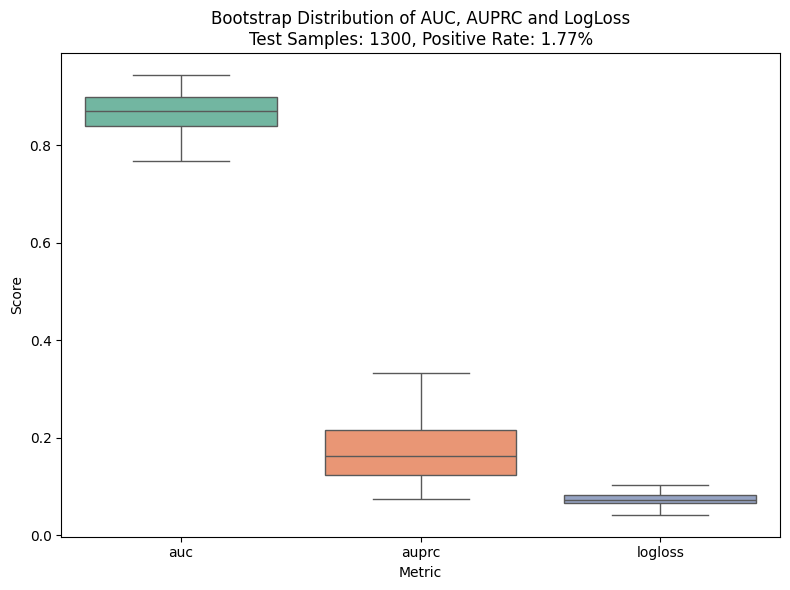

In [38]:

final_model_path = '/content/saved_models_xgboost_single/best_xgboost_73_final.model'
model = xgb.Booster()
model.load_model(final_model_path)

dtest = xgb.DMatrix(X_target_test)


test_preds_proba = model.predict(dtest)


test_auc = roc_auc_score(y_target_test, test_preds_proba)
test_auprc = average_precision_score(y_target_test, test_preds_proba)

print(f"🎯 test AUC: {test_auc:.4f}")
print(f"🎯 test AUPRC: {test_auprc:.4f}")

n_bootstrap = 100
aucs, auprcs, loglosses = [], [], []
rng = np.random.default_rng(seed=42)

for _ in range(n_bootstrap):
    indices = rng.choice(len(y_target_test), size=len(y_target_test), replace=True)
    y_true_boot = y_target_test[indices]
    y_pred_boot = test_preds_proba[indices]

    if len(np.unique(y_true_boot)) < 2:
        continue

    aucs.append(roc_auc_score(y_true_boot, y_pred_boot))
    auprcs.append(average_precision_score(y_true_boot, y_pred_boot))
    loglosses.append(log_loss(y_true_boot, y_pred_boot))

auc_ci = np.percentile(aucs, [2.5, 97.5])
auprc_ci = np.percentile(auprcs, [2.5, 97.5])
logloss_ci = np.percentile(loglosses, [2.5, 97.5])

print(f"✅ test AUC: {test_auc:.4f} (95% CI: {auc_ci[0]:.4f} - {auc_ci[1]:.4f})")
print(f"✅ test AUPRC: {test_auprc:.4f} (95% CI: {auprc_ci[0]:.4f} - {auprc_ci[1]:.4f})")
print(f"✅ test LogLoss: {log_loss(y_target_test, test_preds_proba):.4f} (95% CI: {logloss_ci[0]:.4f} - {logloss_ci[1]:.4f})")

bootstrap_df = pd.DataFrame({
    'auc': aucs,
    'auprc': auprcs,
    'logloss': loglosses
})

!mkdir -p boots_output
csv_path = '/content/boots_output/all-test-73.csv'
bootstrap_df.to_csv(csv_path, index=False)
print(f"📁 bootstrap output saved to: {csv_path}")

shap_values = model.predict(dtest, pred_contribs=True)
shap_df = pd.DataFrame(shap_values, columns=list(X_target_test.columns) + ['bias'])

shap_csv_path = '/content/boots_output/shap_values_all-test-73.csv'
shap_df.to_csv(shap_csv_path, index=False)
print(f"📁 SHAP values saved to: {shap_csv_path}")

# ✅ train SHAP calculation
dtrain = xgb.DMatrix(X_target_train)
shap_values_train = model.predict(dtrain, pred_contribs=True)
shap_train_df = pd.DataFrame(shap_values_train, columns=list(X_target_train.columns) + ['bias'])

shap_train_csv_path = '/content/boots_output/shap_values_all-train-73.csv'
shap_train_df.to_csv(shap_train_csv_path, index=False)
print(f"📁 SHAP for training set saved to: {shap_train_csv_path}")

n_samples = len(y_target_test)
positive_rate = y_target_test.sum() / n_samples

bootstrap_df_long = bootstrap_df.melt(var_name='Metric', value_name='Score')

plt.figure(figsize=(8, 6))
sns.boxplot(data=bootstrap_df_long, x='Metric', y='Score', palette='Set2')
plt.title(f'Bootstrap Distribution of AUC, AUPRC and LogLoss\n'
          f'Test Samples: {n_samples}, Positive Rate: {positive_rate:.2%}')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.tight_layout()
plt.show()


# Cluster

In [39]:
!mkdir model_73

mkdir: cannot create directory ‘model_73’: File exists


In [40]:
!mv /content/saved_models_xgboost_single/best_xgboost_73_final.model /content/model_73/best_xgboost_73_final.model

In [41]:
!rm -r /content/saved_models_xgboost_single

In [42]:
# !rm -r /content/cluster_264/264_7

In [43]:
model_path = '/content/model_73/best_xgboost_73_final.model'
hospital_id = 73

run_shap_umap_hdbscan_analysis(7, model_path, hospital_id)

计算训练集 SHAP 值...
训练集 UMAP 降维...
训练集 HDBSCAN 聚类...
计算验证集 SHAP 值及映射...
计算 train 集合的各簇指标...
train 集合聚类指标保存至：/content/cluster_73/73_7/cluster_metrics_summary_train.csv
✅ SHAP + UMAP + HDBSCAN 聚类分析完成，结果保存在： /content/cluster_73/73_7


# train-all-cluster-performance

In [44]:
evaluate_all_cluster_combinations(
    cluster_csv_path='/content/cluster_73/73_7/sample_cluster_assignments_combined.csv',
    X_target_test=X_target_test.copy(),
    y_target_test=y_target_test,
    model_path='/content/model_73/best_xgboost_73_final.model',
    clusters_to_include=[-1,0,1,2,3,4],
    min_comb_size=1,
    max_comb_size=8,
    n_bootstrap=1000,
    output_dir='/content/cluster_combination-73',
    random_seed=42
)

  0%|          | 0/63 [00:00<?, ?it/s]

缺失的 cluster_id 数量: 0
➡️ 组合 [-1]：样本数 26, Positive Rate: 0.00%
⚠️ 该组合仅包含一个类别 (label=0)，跳过评估
缺失的 cluster_id 数量: 0
➡️ 组合 [0]：样本数 8, Positive Rate: 0.00%
⚠️ 该组合仅包含一个类别 (label=0)，跳过评估
缺失的 cluster_id 数量: 0
➡️ 组合 [1]：样本数 20, Positive Rate: 0.00%
⚠️ 该组合仅包含一个类别 (label=0)，跳过评估
缺失的 cluster_id 数量: 0
➡️ 组合 [2]：样本数 455, Positive Rate: 0.88%
🎯 测试集 AUC: 0.9019
🎯 测试集 AUPRC: 0.3193
🎯 测试集 LogLoss: 0.0405
✅ 测试集 AUC: 0.9019 (95% CI: 0.7122 - 1.0000)
✅ 测试集 AUPRC: 0.3193 (95% CI: 0.0185 - 1.0000)
✅ 测试集 LogLoss: 0.0405 (95% CI: 0.0115 - 0.0829)


  6%|▋         | 4/63 [00:07<01:54,  1.93s/it]

缺失的 cluster_id 数量: 0
➡️ 组合 [3]：样本数 55, Positive Rate: 0.00%
⚠️ 该组合仅包含一个类别 (label=0)，跳过评估
缺失的 cluster_id 数量: 0
➡️ 组合 [4]：样本数 736, Positive Rate: 2.58%
🎯 测试集 AUC: 0.8404
🎯 测试集 AUPRC: 0.1827
🎯 测试集 LogLoss: 0.1021
✅ 测试集 AUC: 0.8404 (95% CI: 0.7477 - 0.9163)
✅ 测试集 AUPRC: 0.1827 (95% CI: 0.0809 - 0.3705)
✅ 测试集 LogLoss: 0.1021 (95% CI: 0.0695 - 0.1423)


 10%|▉         | 6/63 [00:15<02:32,  2.67s/it]

...

缺失的 cluster_id 数量: 0
➡️ 组合 [0, 1, 2, 3, 4]：样本数 1274, Positive Rate: 1.81%
🎯 测试集 AUC: 0.8678
🎯 测试集 AUPRC: 0.1448
🎯 测试集 LogLoss: 0.0751
✅ 测试集 AUC: 0.8678 (95% CI: 0.7844 - 0.9306)
✅ 测试集 AUPRC: 0.1448 (95% CI: 0.0728 - 0.2923)
✅ 测试集 LogLoss: 0.0751 (95% CI: 0.0519 - 0.1023)


 98%|█████████▊| 62/63 [06:47<00:09,  9.79s/it]

缺失的 cluster_id 数量: 0
➡️ 组合 [-1, 0, 1, 2, 3, 4]：样本数 1300, Positive Rate: 1.77%
🎯 测试集 AUC: 0.8672
🎯 测试集 AUPRC: 0.1434
🎯 测试集 LogLoss: 0.0739
✅ 测试集 AUC: 0.8672 (95% CI: 0.7827 - 0.9337)
✅ 测试集 AUPRC: 0.1434 (95% CI: 0.0686 - 0.2942)
✅ 测试集 LogLoss: 0.0739 (95% CI: 0.0496 - 0.0991)


100%|██████████| 63/63 [06:57<00:00,  6.63s/it]

✅ 所有评估完成。结果保存在 /content/cluster_combination-73


# cluster performance

In [45]:
y_train = pd.Series(y_train, index=X_train.index)
y_target_test = pd.Series(y_target_test, index=X_test.index)

In [46]:
retrain_and_evaluate_all_cluster_combinations(
    cluster_csv_path='/content/cluster_73/73_7/sample_cluster_assignments_combined.csv',
    X_train=X_train,
    y_train=y_train,
    X_test=X_target_test,
    y_test=y_target_test,
    clusters_to_include=[-1, 0, 1, 2, 3,4],
    min_comb_size=1,
    max_comb_size=6,
    n_bootstrap=1000,
    output_dir='/content/cluster_combination_retrain_73',
    random_seed=42
)

Cluster combinations:  11%|█         | 7/63 [00:00<00:00, 66.30it/s]


🚀 Cluster 组合重新训练: -1
组合 (-1,) 原始 keep_ids 数量: 59
与 X.index 交集后数量: 59
组合 (-1,) 原始 keep_ids 数量: 26
与 X.index 交集后数量: 26
❌ Cluster -1 失败: 无正样本

🚀 Cluster 组合重新训练: 0
组合 (0,) 原始 keep_ids 数量: 59
与 X.index 交集后数量: 59
组合 (0,) 原始 keep_ids 数量: 8
与 X.index 交集后数量: 8
❌ Cluster 0 失败: 无正样本

🚀 Cluster 组合重新训练: 1
组合 (1,) 原始 keep_ids 数量: 44
与 X.index 交集后数量: 44
组合 (1,) 原始 keep_ids 数量: 20
与 X.index 交集后数量: 20
❌ Cluster 1 失败: 训练样本过少

🚀 Cluster 组合重新训练: 2
组合 (2,) 原始 keep_ids 数量: 1034
与 X.index 交集后数量: 1034
组合 (2,) 原始 keep_ids 数量: 455
与 X.index 交集后数量: 455
❌ Cluster 2 失败: 无正样本

🚀 Cluster 组合重新训练: 3
组合 (3,) 原始 keep_ids 数量: 153
与 X.index 交集后数量: 153
组合 (3,) 原始 keep_ids 数量: 55
与 X.index 交集后数量: 55
❌ Cluster 3 失败: 无正样本

🚀 Cluster 组合重新训练: 4
组合 (4,) 原始 keep_ids 数量: 1684
与 X.index 交集后数量: 1684
组合 (4,) 原始 keep_ids 数量: 736
与 X.index 交集后数量: 736
❌ Cluster 4 失败: 无正样本

🚀 Cluster 组合重新训练: -1_0
组合 (-1, 0) 原始 keep_ids 数量: 118
与 X.index 交集后数量: 118
组合 (-1, 0) 原始 keep_ids 数量: 34
与 X.index 交集后数量: 34
❌ Cluster -1_0 失败: 无正样本

🚀 Cluster 组合重新训


Bootstrap评估: 100%|██████████| 1000/1000 [00:08<00:00, 120.12it/s]



🎯 最终评估结果:
AUROC: nan (95% CI: nan - nan)
AUPRC: 0.0000 (95% CI: 0.0000 - 0.0000)
Accuracy: 1.0000

🔁 使用 train + val 合并数据进行最终训练...
✅ 最终模型已保存: saved_models_xgboost_single/best_xgboost_19_cluster_-1_2_final.model


Cluster combinations:  11%|█         | 7/63 [00:16<00:00, 66.30it/s]

...


🚀 Cluster 组合重新训练: -1_0_1_2_3_4
组合 (-1, 0, 1, 2, 3, 4) 原始 keep_ids 数量: 3033
与 X.index 交集后数量: 3033
组合 (-1, 0, 1, 2, 3, 4) 原始 keep_ids 数量: 1300
与 X.index 交集后数量: 1300
【XGBOOST】单次训练验证开始 - 2025-12-21 04:30:09
✅ 模型输出路径: saved_models_xgboost_single/best_xgboost_19_cluster_-1_0_1_2_3_4.model

🏗️ 训练xgboost模型中...
[0]	train-aucpr:0.20935	train-logloss:0.68558	eval-aucpr:0.03900	eval-logloss:0.68591
[20]	train-aucpr:0.96195	train-logloss:0.54391	eval-aucpr:0.13487	eval-logloss:0.55149
[40]	train-aucpr:0.98932	train-logloss:0.44353	eval-aucpr:0.25691	eval-logloss:0.45795
[60]	train-aucpr:0.99774	train-logloss:0.36425	eval-aucpr:0.19396	eval-logloss:0.38398
[80]	train-aucpr:1.00000	train-logloss:0.30290	eval-aucpr:0.19778	eval-logloss:0.32676
[100]	train-aucpr:1.00000	train-logloss:0.25370	eval-aucpr:0.21806	eval-logloss:0.28096
[120]	train-aucpr:1.00000	train-logloss:0.21665	eval-aucpr:0.21900	eval-logloss:0.24671
[140]	train-aucpr:1.00000	train-logloss:0.18456	eval-aucpr:0.22201	eval-logloss:0.216


Bootstrap评估: 100%|██████████| 1000/1000 [00:07<00:00, 137.90it/s]



🎯 最终评估结果:
AUROC: 0.7993 (95% CI: 0.6223 - 0.9495)
AUPRC: 0.1029 (95% CI: 0.0465 - 0.2859)
Accuracy: 0.9769

🔁 使用 train + val 合并数据进行最终训练...
✅ 最终模型已保存: saved_models_xgboost_single/best_xgboost_19_cluster_-1_0_1_2_3_4_final.model
AUC: 0.8672 (95% CI: 0.7827-0.9337), p=0.0000
AUPRC: 0.1434 (95% CI: 0.0686-0.2942), p=0.0000
LogLoss: 0.0739 (95% CI: 0.0496-0.0991), p=0.0000


Cluster combinations: 100%|██████████| 63/63 [12:52<00:00, 12.27s/it]


✅ 所有 cluster 组合重新训练完成，结果已保存至 /content/cluster_combination_retrain_73


In [47]:
!zip -r eICU-73.zip /content/* -x /content/gossis-1-eicu-only.csv

  adding: content/boots_output/ (stored 0%)
  adding: content/boots_output/shap_values_all-test-73.csv (deflated 62%)
  adding: content/boots_output/shap_values_all-train-73.csv (deflated 62%)
  adding: content/boots_output/all-test-73.csv (deflated 51%)
  adding: content/cluster_73/ (stored 0%)
  adding: content/cluster_73/73_7/ (stored 0%)
  adding: content/cluster_73/73_7/cluster_metrics_summary_train.csv (deflated 71%)
  adding: content/cluster_73/73_7/umap_hdbscan_clusters_train.png (deflated 3%)
  adding: content/cluster_73/73_7/cluster_true_distribution_train.png (deflated 29%)
  adding: content/cluster_73/73_7/sample_cluster_assignments_combined.csv (deflated 75%)
  adding: content/cluster_combination-73/ (stored 0%)
  adding: content/cluster_combination-73/cluster_-1_0_2_4_results_shap.png (deflated 5%)
  adding: content/cluster_combination-73/cluster_-1_1_2_4_results_shap.png (deflated 5%)
  adding: content/cluster_combination-73/cluster_1_2_3_4_results.csv (deflated 54%)
  a